In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
from datetime import datetime

# 1. Data Collection

In [2]:
now = datetime.now()

start = datetime(now.year - 10, now.month, now.day)
end = now
ticker = 'AAPL'
df = yf.download(ticker, start, end)
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-02-01,21.741970,21.805101,21.509737,21.750989,163774000
2016-02-02,21.302305,21.654036,21.257210,21.514245,149428800
2016-02-03,21.723928,21.834408,21.212115,21.419546,183857200
2016-02-04,21.898479,22.063966,21.578844,21.730728,185886800
2016-02-05,21.313614,21.971022,21.238807,21.880345,185672400
...,...,...,...,...,...
2026-01-26,255.410004,256.559998,249.800003,251.479996,55969200
2026-01-27,258.269989,261.950012,258.209991,259.170013,49648300


In [3]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-02-01,21.741970,21.805101,21.509737,21.750989,163774000
2016-02-02,21.302305,21.654036,21.257210,21.514245,149428800
2016-02-03,21.723928,21.834408,21.212115,21.419546,183857200
2016-02-04,21.898479,22.063966,21.578844,21.730728,185886800
2016-02-05,21.313614,21.971022,21.238807,21.880345,185672400


In [4]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-01-26,255.410004,256.559998,249.800003,251.479996,55969200
2026-01-27,258.269989,261.950012,258.209991,259.170013,49648300
2026-01-28,256.440002,258.859985,254.509995,257.649994,41288000
2026-01-29,258.279999,259.649994,254.410004,258.000000,67253000
2026-01-30,259.480011,261.899994,252.179993,255.169998,92352600


# 2. Data Exploration & Visualization

In [5]:
df.shape

(2515, 5)

In [6]:
df.isna().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [7]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2515.000000,2515.000000,2515.000000,2515.000000,2.515000e+03
mean,116.127426,117.279974,114.863197,116.022340,1.001268e+08
std,73.989679,74.697942,73.216845,73.930145,5.593986e+07
min,20.604078,20.907414,20.405656,20.526533,1.791060e+07
25%,41.957258,42.408314,41.716384,41.992380,6.084810e+07
50%,122.343796,123.530475,121.035198,122.294965,8.799110e+07
75%,172.644104,174.738864,171.266137,172.670973,1.223256e+08
max,286.190002,288.619995,283.299988,286.200012,4.584084e+08


In [8]:
df.dtypes

Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

In [9]:
df = df.reset_index()


In [10]:
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2016-02-01,21.741970,21.805101,21.509737,21.750989,163774000
1,2016-02-02,21.302305,21.654036,21.257210,21.514245,149428800
2,2016-02-03,21.723928,21.834408,21.212115,21.419546,183857200
3,2016-02-04,21.898479,22.063966,21.578844,21.730728,185886800
4,2016-02-05,21.313614,21.971022,21.238807,21.880345,185672400


Text(0, 0.5, 'Close Price')

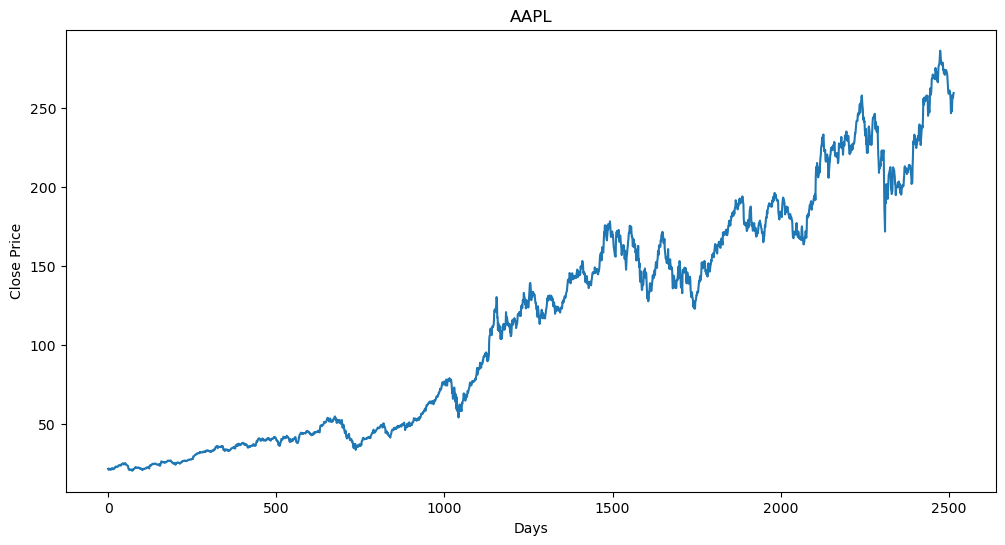

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close)
plt.title(ticker)
plt.xlabel('Days')
plt.ylabel('Close Price')

# 3. Feature Engineering

### Moving Average

## 100 Days Moving Average

In [12]:
df['MA_100'] = df.Close.rolling(100).mean()
df.head(104)

Price,Date,Close,High,Low,Open,Volume,MA_100
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2016-02-01,21.741970,21.805101,21.509737,21.750989,163774000,NaN
1,2016-02-02,21.302305,21.654036,21.257210,21.514245,149428800,NaN
2,2016-02-03,21.723928,21.834408,21.212115,21.419546,183857200,NaN
3,2016-02-04,21.898479,22.063966,21.578844,21.730728,185886800,NaN
4,2016-02-05,21.313614,21.971022,21.238807,21.880345,185672400,NaN
...,...,...,...,...,...,...,...
99,2016-06-22,21.792336,22.097952,21.746720,21.951986,116876400,22.723036
100,2016-06-23,21.917767,21.961101,21.723905,21.881276,128960800,22.724794
101,2016-06-24,21.301979,21.589351,21.130925,21.190224,301245600,22.724790


Text(0, 0.5, 'Close Price')

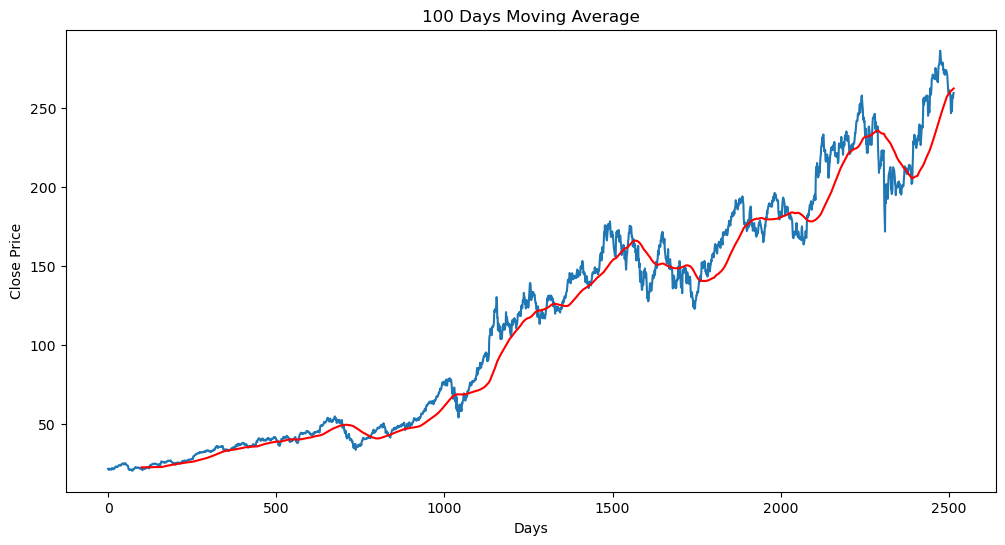

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close)
plt.plot(df.MA_100, 'r')
plt.title("100 Days Moving Average")
plt.xlabel('Days')
plt.ylabel('Close Price')



## 200 Days Moving Average

In [14]:
df['MA_200'] = df.Close.rolling(200).mean()
df.head(204)

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,
0,2016-02-01,21.741970,21.805101,21.509737,21.750989,163774000,NaN,NaN
1,2016-02-02,21.302305,21.654036,21.257210,21.514245,149428800,NaN,NaN
2,2016-02-03,21.723928,21.834408,21.212115,21.419546,183857200,NaN,NaN
3,2016-02-04,21.898479,22.063966,21.578844,21.730728,185886800,NaN,NaN
4,2016-02-05,21.313614,21.971022,21.238807,21.880345,185672400,NaN,NaN
...,...,...,...,...,...,...,...,...
199,2016-11-11,24.991531,25.092946,24.558219,24.689596,136575600,24.649015,23.686025
200,2016-11-14,24.364613,24.848632,23.988922,24.825583,204702000,24.673484,23.699139
201,2016-11-15,24.687298,24.818674,24.468337,24.562835,129058000,24.707337,23.716064


Text(0, 0.5, 'Close Price')

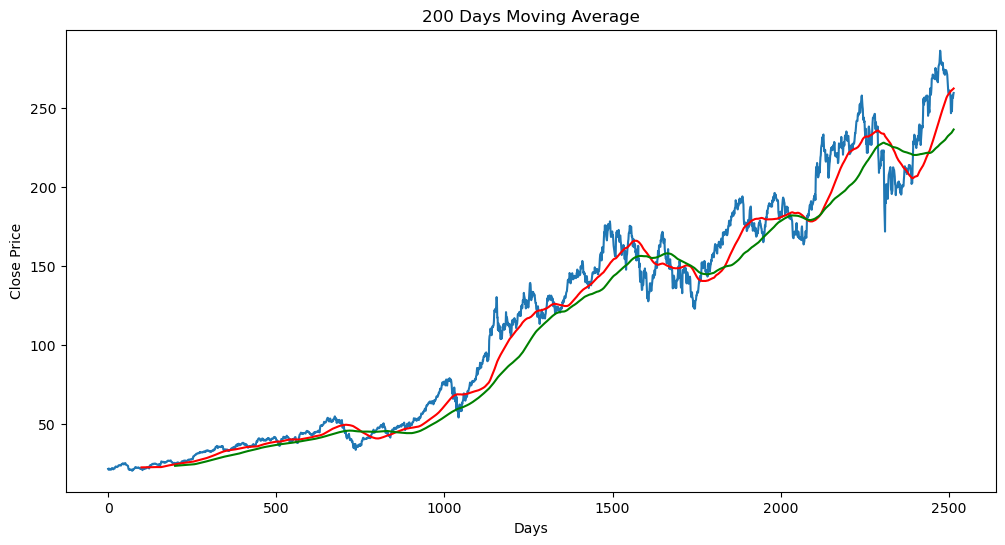

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close)
plt.plot(df.MA_100, 'r')
plt.plot(df.MA_200, 'g')
plt.title("200 Days Moving Average")
plt.xlabel('Days')
plt.ylabel('Close Price')

In [16]:
df

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,
0,2016-02-01,21.741970,21.805101,21.509737,21.750989,163774000,NaN,NaN
1,2016-02-02,21.302305,21.654036,21.257210,21.514245,149428800,NaN,NaN
2,2016-02-03,21.723928,21.834408,21.212115,21.419546,183857200,NaN,NaN
3,2016-02-04,21.898479,22.063966,21.578844,21.730728,185886800,NaN,NaN
4,2016-02-05,21.313614,21.971022,21.238807,21.880345,185672400,NaN,NaN
...,...,...,...,...,...,...,...,...
2510,2026-01-26,255.410004,256.559998,249.800003,251.479996,55969200,261.522423,235.152458
2511,2026-01-27,258.269989,261.950012,258.209991,259.170013,49648300,261.722733,235.452946
2512,2026-01-28,256.440002,258.859985,254.509995,257.649994,41288000,261.891655,235.786291


### Calculating % changed in each trading sessions

In [17]:
df['Percentage Changed'] = df.Close.pct_change()
df[['Close','Percentage Changed']]

Price,Close,Percentage Changed
Ticker,AAPL,
0,21.741970,NaN
1,21.302305,-0.020222
2,21.723928,0.019792
3,21.898479,0.008035
4,21.313614,-0.026708
...,...,...
2510,255.410004,0.029713
2511,258.269989,0.011198
2512,256.440002,-0.007086


Text(0.5, 1.0, 'Percentage Changed')

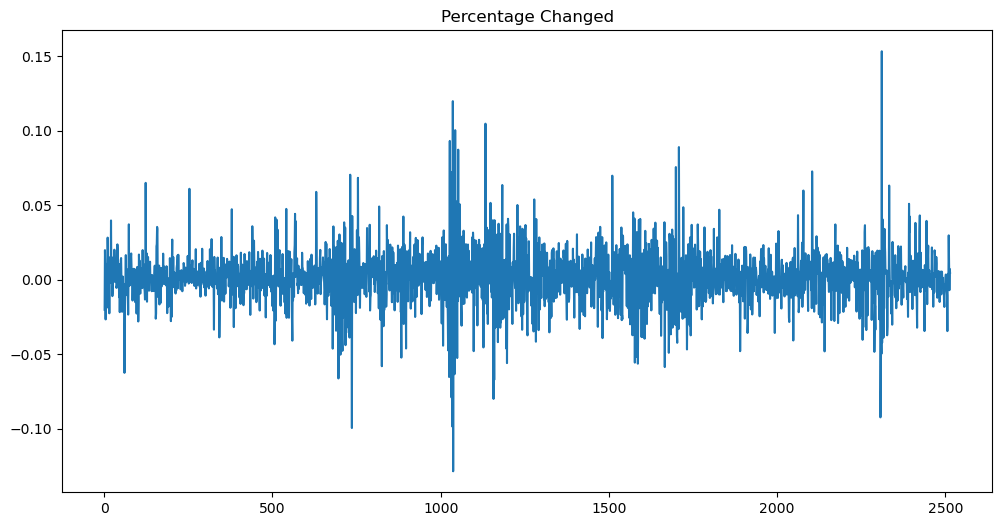

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(df['Percentage Changed'])
plt.title("Percentage Changed")

## 4. Data Preprocessing

In [19]:
df.shape


(2515, 9)

# Spliting data into Training & Testing datasets

In [20]:
data_training = pd.DataFrame(df.Close[0:int(len(df) * 0.7)])
data_testing = pd.DataFrame(df.Close[int(len(df) * 0.7) : int(len(df))])
print(data_training)
print(data_testing)

Ticker        AAPL
0        21.741970
1        21.302305
2        21.723928
3        21.898479
4        21.313614
...            ...
1755    135.820938
1756    139.012848
1757    140.411713
1758    139.751678
1759    141.820480

[1760 rows x 1 columns]
Ticker        AAPL
1760    143.761185
1761    140.874725
1762    142.145538
1763    143.268616
1764    148.578506
...            ...
2510    255.410004
2511    258.269989
2512    256.440002
2513    258.279999
2514    259.480011

[755 rows x 1 columns]


In [21]:
data_training


Ticker,AAPL
0,21.741970
1,21.302305
2,21.723928
3,21.898479
4,21.313614
...,...
1755,135.820938
1756,139.012848
1757,140.411713
1758,139.751678


In [22]:
data_testing

Ticker,AAPL
1760,143.761185
1761,140.874725
1762,142.145538
1763,143.268616
1764,148.578506
...,...
2510,255.410004
2511,258.269989
2512,256.440002
2513,258.279999


### Scaling down the data between 0 & 1

In [23]:

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [24]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.00721709],
       [0.00442851],
       [0.00710266],
       ...,
       [0.75988124],
       [0.75569497],
       [0.76881636]], shape=(1760, 1))

In [25]:
type(data_training_array)

numpy.ndarray

## 5. Sequence Creation

In [26]:
data_training_array.shape

(1760, 1)

In [27]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i, 0])

x_train, y_train = np.array(x_train,), np.array(y_train)

In [28]:
x_train

array([[[0.00721709],
        [0.00442851],
        [0.00710266],
        ...,
        [0.00688557],
        [0.00805729],
        [0.00753653]],

       [[0.00442851],
        [0.00710266],
        [0.00820975],
        ...,
        [0.00805729],
        [0.00753653],
        [0.00833208]],

       [[0.00710266],
        [0.00820975],
        [0.00450024],
        ...,
        [0.00753653],
        [0.00833208],
        [0.00442644]],

       ...,

       [[0.86058331],
        [0.85004117],
        [0.85465743],
        ...,
        [0.71451897],
        [0.7307642 ],
        [0.75100892]],

       [[0.85004117],
        [0.85465743],
        [0.8412457 ],
        ...,
        [0.7307642 ],
        [0.75100892],
        [0.75988124]],

       [[0.85465743],
        [0.8412457 ],
        [0.83326133],
        ...,
        [0.75100892],
        [0.75988124],
        [0.75569497]]], shape=(1660, 100, 1))

In [29]:
y_train

array([0.00833208, 0.00442644, 0.00245909, ..., 0.75988124, 0.75569497,
       0.76881636], shape=(1660,))

In [30]:
x_train.shape

(1660, 100, 1)

In [31]:
y_train.shape

(1660,)

# 6. Model Building

In [34]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [35]:
# ML Model

from keras.models import Sequential
from keras.layers import Dense, LSTM, Input

In [36]:
model = Sequential()

model.add(Input(shape=(100,1)))
model.add(LSTM(units=128, activation='tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))


# 7. Model Training

In [37]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 18s 192ms/step - loss: 0.0147
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 196ms/step - loss: 6.8126e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 194ms/step - loss: 6.1684e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 191ms/step - loss: 5.8803e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 272ms/step - loss: 6.1802e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 185ms/step - loss: 5.4293e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 240ms/step - loss: 5.2835e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 16s 316ms/step - loss: 5.2464e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 244ms/step - loss: 6.2442e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 195ms/step - loss: 4.5828e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 202ms/step - loss: 4.9183e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 195ms/step - loss: 4.4237e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 196ms/step - loss: 4.7995e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 197ms/step - loss: 4.

In [38]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                       │ (None, 100, 128)         │        66,560 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                     │ (None, 64)               │        49,408 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 25)               │         1,625 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_1 (Dense)                   │ (None, 1)                │            26 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [40]:
#  Save the trained model
model.save('stock_prediction_model.keras')

#  8. Preparing Test Data

In [44]:
data_training

Ticker,AAPL
0,21.741970
1,21.302305
2,21.723928
3,21.898479
4,21.313614
...,...
1755,135.820938
1756,139.012848
1757,140.411713
1758,139.751678


In [45]:
data_training.tail(100)

Ticker,AAPL
1660,153.240143
1661,151.981277
1662,153.387650
1663,151.912430
1664,154.774399
...,...
1755,135.820938
1756,139.012848
1757,140.411713
1758,139.751678


In [41]:
data_testing

Ticker,AAPL
1760,143.761185
1761,140.874725
1762,142.145538
1763,143.268616
1764,148.578506
...,...
2510,255.410004
2511,258.269989
2512,256.440002
2513,258.279999


In [46]:
past_100_days = data_training.tail(100)

In [47]:
past_100_days

Ticker,AAPL
1660,153.240143
1661,151.981277
1662,153.387650
1663,151.912430
1664,154.774399
...,...
1755,135.820938
1756,139.012848
1757,140.411713
1758,139.751678


In [49]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)

In [50]:
final_df

Ticker,AAPL
0,153.240143
1,151.981277
2,153.387650
3,151.912430
4,154.774399
...,...
850,255.410004
851,258.269989
852,256.440002
853,258.279999


In [51]:
input_data = scaler.fit_transform(final_df)
input_data.shape

(855, 1)

In [52]:
input_data

array([[1.84497042e-01],
       [1.76775271e-01],
       [1.85401836e-01],
       [1.76352965e-01],
       [1.93908036e-01],
       [2.30466483e-01],
       [1.72612398e-01],
       [1.81480721e-01],
       [1.63744261e-01],
       [1.53669578e-01],
       [1.76473330e-01],
       [1.91072823e-01],
       [1.71888806e-01],
       [1.65976528e-01],
       [1.52040631e-01],
       [1.54092070e-01],
       [1.60064344e-01],
       [1.48481546e-01],
       [1.04080588e-01],
       [7.82605147e-02],
       [1.03899574e-01],
       [1.25919272e-01],
       [1.27729046e-01],
       [1.21877231e-01],
       [8.96622037e-02],
       [9.16531799e-02],
       [8.29660584e-02],
       [7.91050323e-02],
       [1.07157186e-01],
       [7.93463230e-02],
       [1.03658470e-01],
       [1.11742084e-01],
       [1.12405774e-01],
       [1.09570467e-01],
       [1.32977447e-01],
       [1.46128821e-01],
       [1.63563434e-01],
       [1.45525688e-01],
       [1.18076574e-01],
       [1.84074830e-01],


In [54]:
x_test = []
y_test = []
for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i, 0])

In [55]:
x_test, y_test = np.array(x_test), np.array(y_test)


In [56]:
x_test

array([[[0.18449704],
        [0.17677527],
        [0.18540184],
        ...,
        [0.10580856],
        [0.10175997],
        [0.11444982]],

       [[0.17677527],
        [0.18540184],
        [0.17635297],
        ...,
        [0.10175997],
        [0.11444982],
        [0.12635393]],

       [[0.18540184],
        [0.17635297],
        [0.19390804],
        ...,
        [0.11444982],
        [0.12635393],
        [0.10864864]],

       ...,

       [[0.71390061],
        [0.71334914],
        [0.70225753],
        ...,
        [0.76599114],
        [0.81119815],
        [0.82874105]],

       [[0.71334914],
        [0.70225753],
        [0.68062579],
        ...,
        [0.81119815],
        [0.82874105],
        [0.81751607]],

       [[0.70225753],
        [0.68062579],
        [0.63429825],
        ...,
        [0.82874105],
        [0.81751607],
        [0.82880245]]], shape=(755, 100, 1))

In [57]:
y_test

array([0.12635393, 0.10864864, 0.1164437 , 0.12333256, 0.15590297,
       0.17814037, 0.16140164, 0.17904675, 0.16255016, 0.15620491,
       0.15844438, 0.17563199, 0.17169815, 0.18458895, 0.17478467,
       0.1677644 , 0.1431329 , 0.14573516, 0.14870065, 0.13242083,
       0.1397437 , 0.13665718, 0.12394804, 0.12757939, 0.15856531,
       0.17551107, 0.16201526, 0.16970109, 0.15590259, 0.14325383,
       0.15517629, 0.16800653, 0.1704273 , 0.18773603, 0.18259161,
       0.19711651, 0.20849415, 0.19971876, 0.20637578, 0.21436477,
       0.20244232, 0.1986293 , 0.21751185, 0.22713428, 0.24250631,
       0.25019242, 0.24692442, 0.23560716, 0.24105389, 0.22513703,
       0.21769333, 0.21345689, 0.24650052, 0.24438244, 0.24450356,
       0.25200781, 0.25902827, 0.25309727, 0.24323252, 0.24510884,
       0.23566781, 0.23560716, 0.26374869, 0.27143471, 0.27089017,
       0.26453565, 0.25793881, 0.24789249, 0.29497694, 0.29455323,
       0.28408338, 0.29491647, 0.2960663 , 0.29036967, 0.28733

In [61]:
x_test[0].shape

(100, 1)

#  9. Making Predictions

In [62]:
y_predicted = model.predict(x_test)
y_predicted

24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step


array([[0.09885652],
       [0.10801133],
       [0.1094291 ],
       [0.11023161],
       [0.11262242],
       [0.12485857],
       [0.14386518],
       [0.15384118],
       [0.16356719],
       [0.1643845 ],
       [0.16002166],
       [0.15616088],
       [0.1592726 ],
       [0.16226245],
       [0.16868001],
       [0.17087668],
       [0.16881514],
       [0.15807717],
       [0.14917243],
       [0.1445561 ],
       [0.13763353],
       [0.13458745],
       [0.13279505],
       [0.12811747],
       [0.12515272],
       [0.13322215],
       [0.14792764],
       [0.15594567],
       [0.16176185],
       [0.16027087],
       [0.15276404],
       [0.1495848 ],
       [0.15276885],
       [0.15775068],
       [0.16754232],
       [0.17402579],
       [0.18232913],
       [0.19230153],
       [0.19630022],
       [0.1993984 ],
       [0.20383061],
       [0.20283772],
       [0.19927737],
       [0.20276597],
       [0.21052657],
       [0.22254348],
       [0.23455861],
       [0.241

In [63]:
y_test

array([0.12635393, 0.10864864, 0.1164437 , 0.12333256, 0.15590297,
       0.17814037, 0.16140164, 0.17904675, 0.16255016, 0.15620491,
       0.15844438, 0.17563199, 0.17169815, 0.18458895, 0.17478467,
       0.1677644 , 0.1431329 , 0.14573516, 0.14870065, 0.13242083,
       0.1397437 , 0.13665718, 0.12394804, 0.12757939, 0.15856531,
       0.17551107, 0.16201526, 0.16970109, 0.15590259, 0.14325383,
       0.15517629, 0.16800653, 0.1704273 , 0.18773603, 0.18259161,
       0.19711651, 0.20849415, 0.19971876, 0.20637578, 0.21436477,
       0.20244232, 0.1986293 , 0.21751185, 0.22713428, 0.24250631,
       0.25019242, 0.24692442, 0.23560716, 0.24105389, 0.22513703,
       0.21769333, 0.21345689, 0.24650052, 0.24438244, 0.24450356,
       0.25200781, 0.25902827, 0.25309727, 0.24323252, 0.24510884,
       0.23566781, 0.23560716, 0.26374869, 0.27143471, 0.27089017,
       0.26453565, 0.25793881, 0.24789249, 0.29497694, 0.29455323,
       0.28408338, 0.29491647, 0.2960663 , 0.29036967, 0.28733

In [64]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1, 1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()


In [65]:
y_predicted

array([139.27834, 140.77083, 141.00197, 141.1328 , 141.52257, 143.5174 ,
       146.61601, 148.24237, 149.82799, 149.96124, 149.24997, 148.62054,
       149.12785, 149.61528, 150.66151, 151.01964, 150.68355, 148.93295,
       147.48123, 146.72864, 145.60008, 145.10347, 144.81126, 144.04869,
       143.56535, 144.88089, 147.2783 , 148.58546, 149.53368, 149.29059,
       148.06677, 147.54846, 148.06755, 148.87975, 150.47604, 151.53304,
       152.88672, 154.5125 , 155.1644 , 155.66948, 156.39206, 156.2302 ,
       155.64975, 156.21849, 157.48369, 159.44278, 161.40158, 162.47069,
       162.19644, 161.94714, 160.81236, 159.40683, 158.1861 , 159.38129,
       160.75891, 161.76167, 162.76646, 163.82802, 164.13852, 163.50264,
       162.93068, 161.99568, 161.30019, 162.61366, 164.51791, 165.90553,
       166.24756, 165.74252, 164.54646, 166.49553, 168.57172, 169.27345,
       170.02574, 170.5458 , 170.41557, 169.95367, 169.57129, 169.59715,
       170.65327, 171.64642, 171.88393, 170.79395, 

In [66]:
y_test

array([143.76118469, 140.87472534, 142.14553833, 143.26861572,
       148.57850647, 152.2038269 , 149.47494507, 152.35159302,
       149.66218567, 148.62773132, 148.99282837, 151.79489136,
       151.15356445, 153.25512695, 151.65675354, 150.51225281,
       146.49662781, 146.92086792, 147.40432739, 144.7502594 ,
       145.9440918 , 145.44090271, 143.36895752, 143.96096802,
       149.01254272, 151.775177  , 149.57498169, 150.82798767,
       148.57844543, 146.51634216, 148.46003723, 150.55172729,
       150.94638062, 153.76818848, 152.92950439, 155.29747009,
       157.15234375, 155.72171021, 156.80699158, 158.10942078,
       156.16572571, 155.5440979 , 158.6224823 , 160.19120789,
       162.69728088, 163.95033264, 163.41755676, 161.57252502,
       162.460495  , 159.86560059, 158.65206909, 157.96141052,
       163.34844971, 163.00314331, 163.02288818, 164.24629211,
       165.39082336, 164.42390442, 162.81567383, 163.12156677,
       161.58241272, 161.57252502, 166.16038513, 167.41

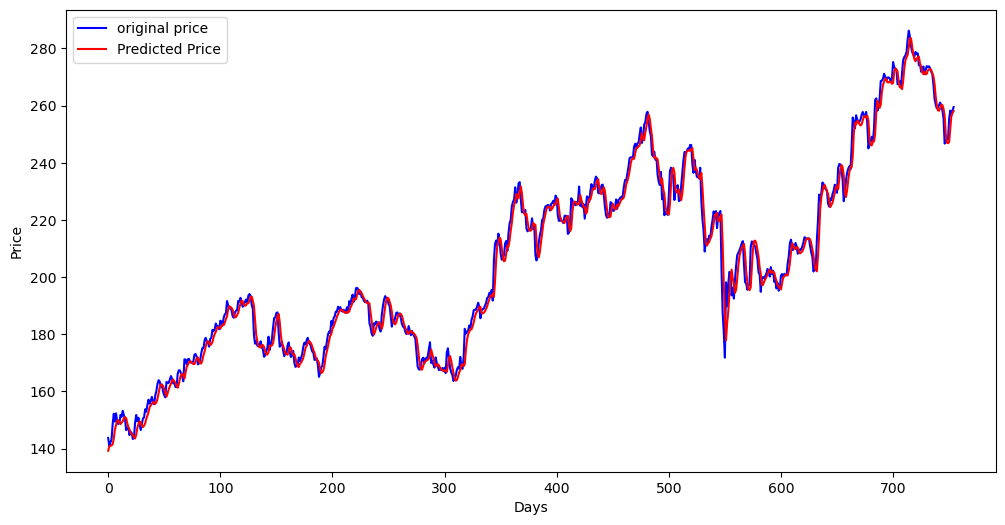

In [71]:
plt.figure(figsize = (12, 6))
plt.plot(y_test, 'b', label='original price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()

(140.0, 220.0)

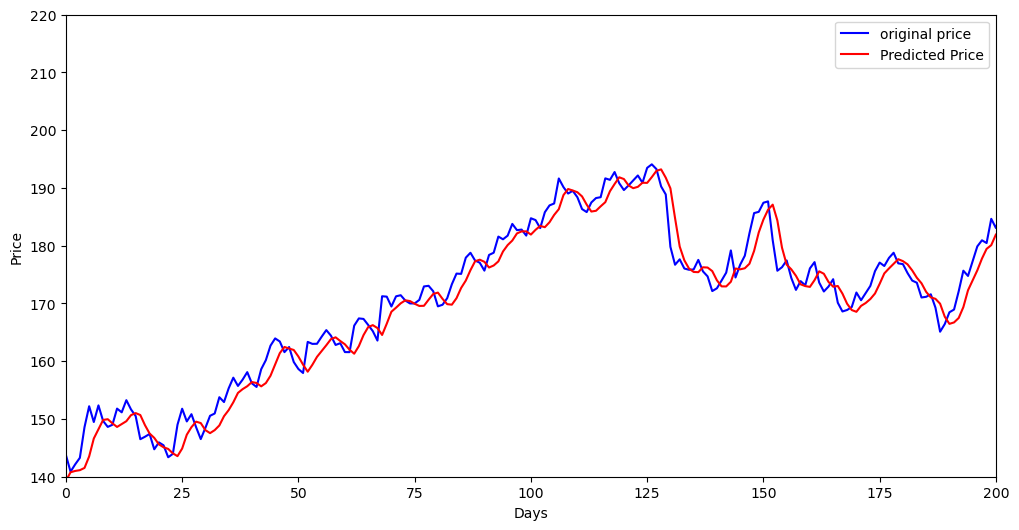

In [70]:
plt.figure(figsize = (12, 6))
plt.plot(y_test, 'b', label='original price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.xlim(0, 200)
plt.ylim(140, 220)

#  10. Model Evaluation

In [76]:
# Mean Squared Error (MSE)

from sklearn.metrics import mean_squared_error, r2_score

In [73]:
mse = mean_squared_error(y_test, y_predicted)

In [74]:
mse


15.357876950673855

In [75]:
#  Root Mean Squared Error (RMSC)

rmse = np.sqrt(mse)
rmse


np.float64(3.918912725575023)

In [77]:
#   R-Squared

r2 = r2_score(y_test, y_predicted)
r2

0.9864851014480756